# 📊 DATA CLEANING PROJECT — MYINSIGHT 2026 RTD TEA VIỆT NAM
#### 📁 Cấu trúc thư mục dự án (Project Directory Structure):
```text
data_clean/
├── raw/                      # Chứa 3 file dữ liệu gốc (đã được đổi tên chuẩn hóa)
│   ├── Brandlist_RTDT.csv
│   ├── Dataset.csv
│   └── QNR_Reference.csv
├── notebooks/                # Chứa Jupyter Notebook xử lý
│   └── data_cleaning.ipynb
├── output/                   # Chứa các file kết quả sạch sau khi xử lý
│   ├── Dataset_cleaned.csv
│   ├── Brandlist_cleaned.csv
│   ├── QNR_Reference_cleaned.csv
│   ├── cleaning_report_myInsight2026.xlsx
│   └── data_dictionary_cleaning_log.xlsx
└── charts/                   # Chứa biểu đồ báo cáo chất lượng dữ liệu
    └── data_quality_before_clean.png
```

#### 💡 Phát hiện đặc biệt quan trọng (Crucial Insight):
*   **Lỗi định dạng cột `Serial number`**: Cột serial number trong dữ liệu gốc có dạng chuỗi `1,00`, `2,00` (dùng dấu phẩy làm phần thập phân theo định dạng châu Âu/Việt Nam). Nếu chuyển trực tiếp bằng `pd.to_numeric` sẽ bị ép về `NaN`, dẫn đến việc xóa sạch 99.9% dòng dữ liệu khi loại bỏ trùng lặp. **Chúng tôi đã khắc phục triệt để bằng cách thay thế `,` thành `.` trước khi chuyển đổi.**
*   **Routing logic của bảng hỏi**: Giá trị `#NULL!` đại diện cho các câu hỏi không được hỏi (routing skip), không phải missing value thực sự. Chúng tôi chuyển thành `np.nan` nhưng giữ nguyên không điền khuyết để đảm bảo tính toán **base** chính xác khi phân tích (ví dụ: base tính P3M/P4W phải là người nhận biết thương hiệu đó).


In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
from scipy import stats
from IPython.display import display
from openpyxl.utils import get_column_letter

warnings.filterwarnings('ignore')

# Cấu hình hiển thị
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Khởi tạo đường dẫn tương đối từ folder notebooks
PATH_BRAND  = '../raw/Brandlist_RTDT.csv'
PATH_DATA   = '../raw/Dataset.csv'
PATH_QNR    = '../raw/QNR_Reference.csv'

print("✅ Setup & Import completed successfully!")


✅ Setup & Import completed successfully!


## 📥 CELL 1 — LOAD RAW DATA
Đọc cả 3 file dữ liệu khảo sát từ thư mục `raw/` và in ra thông tin cấu trúc cơ bản của từng bảng.


In [3]:
# Load cả 3 file
df_brand = pd.read_csv(PATH_BRAND)
df_data  = pd.read_csv(PATH_DATA)
df_qnr   = pd.read_csv(PATH_QNR)

# In thông tin cơ bản từng file
for name, df in [('BRANDLIST', df_brand),
                 ('DATASET',   df_data),
                 ('QNR_REF',   df_qnr)]:
    print(f"\n{'='*50}")
    print(f"TABLE: {name}")
    print(f"Shape : {df.shape}")
    print(f"Columns sample: {list(df.columns[:10])}")
    print(df.head(3).to_string())



TABLE: BRANDLIST
Shape : (55, 2)
Columns sample: ['Brandlist', 'Unnamed: 1']
   Brandlist              Unnamed: 1
0          1                      C2
1          2  C2 - Không xác định   
2          3        C2 - Vị chanh   

TABLE: DATASET
Shape : (2600, 1068)
Columns sample: ['Serial number', 'Wave', 'Region', 'D4.Income', 'D2.Gender', 'D3.Age', 'S2.Category used in P4W_Juice (freshly made)', 'S2.Category used in P4W_RTD Juice (can, bottle, tetra pak)', 'S2.Category used in P4W_Juice (powder)', 'S2.Category used in P4W_Carbonated soft drink']
  Serial number  Wave  Region                    D4.Income D2.Gender        D3.Age S2.Category used in P4W_Juice (freshly made) S2.Category used in P4W_RTD Juice (can, bottle, tetra pak) S2.Category used in P4W_Juice (powder) S2.Category used in P4W_Carbonated soft drink S2.Category used in P4W_Purified water (less than 1.5 liter) S2.Category used in P4W_Branded water bottle (5 - 20 liter) S2.Category used in P4W_RTD Herbal Tea S2.Category used

## 🏷️ CELL 2 — CLEAN FILE 1: BRANDLIST
Tiến hành chuẩn hóa danh mục thương hiệu, phân tách Master Brand và các sản phẩm SKU cụ thể.


In [4]:
df_brand_clean = df_brand.copy()

# Bước 1: Đổi tên cột cho rõ ràng
df_brand_clean.columns = ['brand_id', 'brand_name']

# Bước 2: Xử lý brand_name - Trim khoảng trắng thừa
df_brand_clean['brand_name'] = df_brand_clean['brand_name'].str.strip()

# Bước 3: Xử lý brand_id - Đảm bảo là integer và bỏ dòng null
df_brand_clean = df_brand_clean.dropna(subset=['brand_id'])
df_brand_clean['brand_id'] = df_brand_clean['brand_id'].astype(int)

# Bước 4: Phân loại master brand vs SKU
# - SKU có chứa ký tự " - " hoặc " – " trong tên
df_brand_clean['is_master_brand'] = ~df_brand_clean['brand_name'].str.contains(' - | – ', na=False)
df_brand_clean['master_brand'] = df_brand_clean['brand_name'].apply(
    lambda x: x.split(' - ')[0].split(' – ')[0].strip() if (' - ' in str(x) or ' – ' in str(x)) else x
)

# Bước 5: Tạo mapping dict phục vụ tra cứu sau này
brand_mapping = dict(zip(
    df_brand_clean['brand_id'], 
    df_brand_clean['brand_name']
))

print("✅ BRANDLIST cleaned")
print(f"   Total rows: {len(df_brand_clean)}")
print(f"   Master brands: {df_brand_clean['is_master_brand'].sum()}")
print(f"   SKUs: {(~df_brand_clean['is_master_brand']).sum()}")
display(df_brand_clean.head(10))


✅ BRANDLIST cleaned
   Total rows: 55
   Master brands: 33
   SKUs: 22


,brand_id,brand_name,is_master_brand,master_brand
0,1,C2,True,C2
1,2,C2 - Không xác định,False,C2
2,3,C2 - Vị chanh,False,C2
3,4,C2 - Vị táo,False,C2
4,34,C2 - Vị đào,False,C2
5,5,C2 - Olong Hoa hồng,False,C2
6,6,C2 - Olong Chanh,False,C2
7,29,C2 – Hồng Trà,False,C2
8,30,C2 – Hồng Trà Đào,False,C2
9,33,C2 – Hồng Trà Vải,False,C2


## 📖 CELL 3 — CLEAN FILE 3: QNR REFERENCE
Chuẩn hóa bảng lookup câu hỏi, sửa lỗi merge cell bằng phương pháp forward fill (`ffill`).


In [5]:
df_qnr_clean = df_qnr.copy()

# Bước 1: Đổi tên cột
df_qnr_clean.columns = [
    'question_code', 'sub_code',
    'question_text', 'answer_text', 
    'answer_code'
]

# Bước 2: Trim tất cả các cột string
str_cols = df_qnr_clean.select_dtypes('object').columns
for col in str_cols:
    df_qnr_clean[col] = df_qnr_clean[col].str.strip()

# Bước 3: Forward fill cho các dòng bị null do merge cell trong Excel
df_qnr_clean['question_code'] = df_qnr_clean['question_code'].ffill()
df_qnr_clean['question_text'] = df_qnr_clean['question_text'].ffill()

# Bước 4: Tạo dict tra cứu nhanh câu hỏi
qnr_lookup = dict(zip(
    df_qnr_clean['question_code'],
    df_qnr_clean['question_text']
))

print("✅ QNR REFERENCE cleaned")
print(f"   Unique questions: {df_qnr_clean['question_code'].nunique()}")
display(df_qnr_clean.head(10))


✅ QNR REFERENCE cleaned
   Unique questions: 23


,question_code,sub_code,question_text,answer_text,answer_code
0,Wave,NaN,Năm thực hiện PV,NaN,NaN
1,Region,NaN,Khu vực thực hiện PV,NaN,NaN
2,D2,NaN,Giới tính,NaN,NaN
3,D3,NaN,Độ tuổi,NaN,NaN
4,D4,NaN,Thu nhập hộ gia đình,NaN,NaN
5,S2,NaN,Những loại sản phẩm nào bạn đã uống trong 4 tu...,NaN,NaN
6,S3b,NaN,Bạn uống trà uống liền (đóng chai/lon/hộp...,NaN,NaN
7,S3b,NaN,Bạn uống trà uống liền (đóng chai/lon/hộp...,Hằng ngày,1
8,S3b,NaN,Bạn uống trà uống liền (đóng chai/lon/hộp...,Once per day,NaN
9,S3b,NaN,Bạn uống trà uống liền (đóng chai/lon/hộp...,4-6 lần mỗi tuần,2


## 🗂️ CELL 4 — PHÂN LOẠI CỘT DATASET (Data Dictionary)
Tự động nhóm 1068 cột trong bảng dữ liệu khảo sát chính thành các nhóm chỉ số nghiên cứu thị trường tiêu chuẩn.


In [6]:
# Phân loại tất cả 1068 cột theo prefix để quản lý
col_groups = {
    'ID'         : [],
    'DIM_Demo'   : [],
    'DIM_Screen' : [],
    'Q1_TOM'     : [],
    'Q1_Spont'   : [],
    'Q1Q2_Aided' : [],
    'Q3_P3M'     : [],
    'Q4_P4W'     : [],
    'Q5_BUMO'    : [],
    'Q6_Consid'  : [],
    'Q7_PrevBUMO': [],
    'Q4Q8_BCS'   : [],
    'QI_Imagery' : [],
    'QME2_Barrier': [],
    'QTP1_Touch' : [],
    'QTP2_PurchCh': [],
    'QTP3_Occas' : [],
    'OTHER'      : [],
}

for col in df_data.columns:
    c = col.strip()
    if c == 'Serial number':
        col_groups['ID'].append(col)
    elif c in ['Wave','Region','D2.Gender','D3.Age',
               'D4.Income','- D6.Occupation',
               'D7.Educational level']:
        col_groups['DIM_Demo'].append(col)
    elif c.startswith('S2.') or c.startswith('S3'):
        col_groups['DIM_Screen'].append(col)
    elif c == 'Q1.TOM':
        col_groups['Q1_TOM'].append(col)
    elif c.startswith('Q1.Total Spontaneous') or c.startswith('Q1.TotalSpontaneous'):
        col_groups['Q1_Spont'].append(col)
    elif c.startswith('Q1Q2.'):
        col_groups['Q1Q2_Aided'].append(col)
    elif c.startswith('Q3.'):
        col_groups['Q3_P3M'].append(col)
    elif c.startswith('Q4. P4W') or c.startswith('Q4.P4W'):
        col_groups['Q4_P4W'].append(col)
    elif c.startswith('Q5.'):
        col_groups['Q5_BUMO'].append(col)
    elif c.startswith('Q6 -') or c.startswith('Q6-'):
        col_groups['Q6_Consid'].append(col)
    elif c.startswith('Q7.'):
        col_groups['Q7_PrevBUMO'].append(col)
    elif c.startswith('Q4Q8.'):
        col_groups['Q4Q8_BCS'].append(col)
    elif c.startswith('QI -') or c.startswith('QI-'):
        col_groups['QI_Imagery'].append(col)
    elif c.startswith('QME2 -') or c.startswith('QME2-'):
        col_groups['QME2_Barrier'].append(col)
    elif c.startswith('Q_TP1'):
        col_groups['QTP1_Touch'].append(col)
    elif c.startswith('Q_TP2'):
        col_groups['QTP2_PurchCh'].append(col)
    elif c.startswith('Q_TP3'):
        col_groups['QTP3_Occas'].append(col)
    else:
        col_groups['OTHER'].append(col)

print("📊 CỘT THEO NHÓM:")
for grp, cols in col_groups.items():
    print(f"   {grp:<15}: {len(cols):>4} cột")
print(f"\n   TỔNG              : {sum(len(v) for v in col_groups.values())} cột")


📊 CỘT THEO NHÓM:
   ID             :    1 cột
   DIM_Demo       :    7 cột
   DIM_Screen     :   30 cột
   Q1_TOM         :    1 cột
   Q1_Spont       :   57 cột
   Q1Q2_Aided     :   57 cột
   Q3_P3M         :   16 cột
   Q4_P4W         :   56 cột
   Q5_BUMO        :    1 cột
   Q6_Consid      :   15 cột
   Q7_PrevBUMO    :    1 cột
   Q4Q8_BCS       :   16 cột
   QI_Imagery     :  285 cột
   QME2_Barrier   :  225 cột
   QTP1_Touch     :  270 cột
   QTP2_PurchCh   :   15 cột
   QTP3_Occas     :   15 cột
   OTHER          :    0 cột

   TỔNG              : 1068 cột


## 🛠️ CELL 5 — XỬ LÝ GIÁ TRỊ "#NULL!" & CHUYỂN Yes/No ➜ 0/1
*   Chuyển chuỗi `#NULL!` đại diện cho phần bỏ qua câu hỏi (skip logic) thành định dạng chuẩn `np.nan` của pandas để tránh bị hiểu nhầm là chuỗi văn bản thường.
*   Chuyển đổi toàn bộ các cột chỉ số dạng flag (`Yes`/`No`) thành giá trị nhị phân `1`/`0` để tối ưu bộ nhớ và hỗ trợ tính toán trung bình (`mean`) nhanh chóng khi tính tỷ lệ phần trăm nhận biết/tiêu dùng.


In [7]:
df_clean = df_data.copy()

# Đếm số lượng ô chứa "#NULL!" trước khi chuyển đổi
null_str_count = (df_clean == '#NULL!').sum().sum()
print(f"⚠️ Tổng ô chứa '#NULL!': {null_str_count:,}")

# Thay thế sang np.nan chuẩn của pandas
df_clean = df_clean.replace('#NULL!', np.nan)

# Tổng hợp danh sách cột flag cần chuyển đổi Yes/No -> 1/0
flag_cols = (
    col_groups['Q1_Spont'] +
    col_groups['Q1Q2_Aided'] +
    col_groups['Q3_P3M'] +
    col_groups['Q4_P4W'] +
    col_groups['Q4Q8_BCS'] +
    col_groups['QI_Imagery'] +
    col_groups['QME2_Barrier'] +
    col_groups['QTP1_Touch'] +
    col_groups['DIM_Screen']
)

yes_no_map = {'Yes': 1, 'No': 0, 'yes': 1, 'no': 0,
              'YES': 1, 'NO': 0, True: 1, False: 0}

converted = 0
for col in flag_cols:
    if col in df_clean.columns:
        unique_vals = df_clean[col].dropna().unique()
        unique_vals_set = set(str(v).strip().lower() for v in unique_vals)
        if unique_vals_set <= {'yes', 'no'}:
            df_clean[col] = df_clean[col].map(yes_no_map)
            converted += 1

print(f"✅ Đã convert {converted} cột Yes/No → 0/1")

# Clean riêng các cột định tính (string)
for col in ['Q1.TOM', 'Q5.Bumo', 'Q7. Previous BUMO']:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].str.strip()


⚠️ Tổng ô chứa '#NULL!': 1,346,028
✅ Đã convert 1011 cột Yes/No → 0/1


## 👥 CELL 6 — CLEAN CỘT DIM (Demographics)
*   Đổi tên các cột nhân khẩu học chính sang dạng ngắn dễ thao tác.
*   **Đặc biệt sửa lỗi cột `Serial number`**: Cột `Serial number` gốc chứa chuỗi như `1,00`, `2,00`. Bằng cách thay thế dấu phẩy `,` thành dấu chấm `.`, pandas có thể chuyển đổi thành số nguyên chính xác thay vì bị ép kiểu thành `NaN`.


In [8]:
# Đổi tên các cột thông tin nhân khẩu học
rename_map = {
    'Serial number'    : 'serial',
    'Wave'             : 'wave',
    'Region'           : 'region',
    'D2.Gender'        : 'gender',
    'D3.Age'           : 'age_group',
    'D4.Income'        : 'income',
    '- D6.Occupation'  : 'occupation',
    'D7.Educational level': 'education',
}
df_clean = df_clean.rename(columns=rename_map)

# Wave: chuyển sang Int64
df_clean['wave'] = pd.to_numeric(
    df_clean['wave'], errors='coerce'
).astype('Int64')

# SỬA LỖI SERIAL NUMBER: Thay ',' bằng '.' trước khi chuyển sang Int64
df_clean['serial'] = pd.to_numeric(
    df_clean['serial'].astype(str).str.replace(',', '.', regex=False), 
    errors='coerce'
).round().astype('Int64')

# region: viết hoa chữ cái đầu và trim
df_clean['region'] = df_clean['region'].str.strip().str.title()
print("Unique regions:", df_clean['region'].unique())

# gender, age_group, income, occupation, education: trim khoảng trắng
df_clean['gender'] = df_clean['gender'].str.strip()
df_clean['age_group'] = df_clean['age_group'].str.strip()
df_clean['income'] = df_clean['income'].str.strip()
df_clean['occupation'] = df_clean['occupation'].str.strip()
df_clean['education'] = df_clean['education'].str.strip()

# Chuẩn hóa cột tần suất uống trà uống liền S3b
s3b_col = [c for c in df_clean.columns if 'S3b' in c]
if s3b_col:
    df_clean[s3b_col[0]] = df_clean[s3b_col[0]].str.strip()
    print(f"S3b unique values: {df_clean[s3b_col[0]].unique()}")

print("\n✅ Cột thông tin DIM đã được làm sạch thành công!")


Unique regions: ['South' 'Mekong' 'North' 'Central']
S3b unique values: ['Once per day' '2-3 times/week' '4-6 times/ week' 'Once per week'
 '2-3 times/month' 'Once per month']

✅ Cột thông tin DIM đã được làm sạch thành công!


## 📊 CELL 7 — BIỂU ĐỒ BÁO CÁO CHẤT LƯỢNG DỮ LIỆU
Vẽ hệ thống 4 biểu đồ phản ánh tình hình dữ liệu hiện tại, phân phối mẫu theo khu vực địa lý, độ tuổi và so sánh tỷ lệ thâm nhập 4 tuần qua (P4W) của các thương hiệu hàng đầu so với Cozy (Focal Brand).


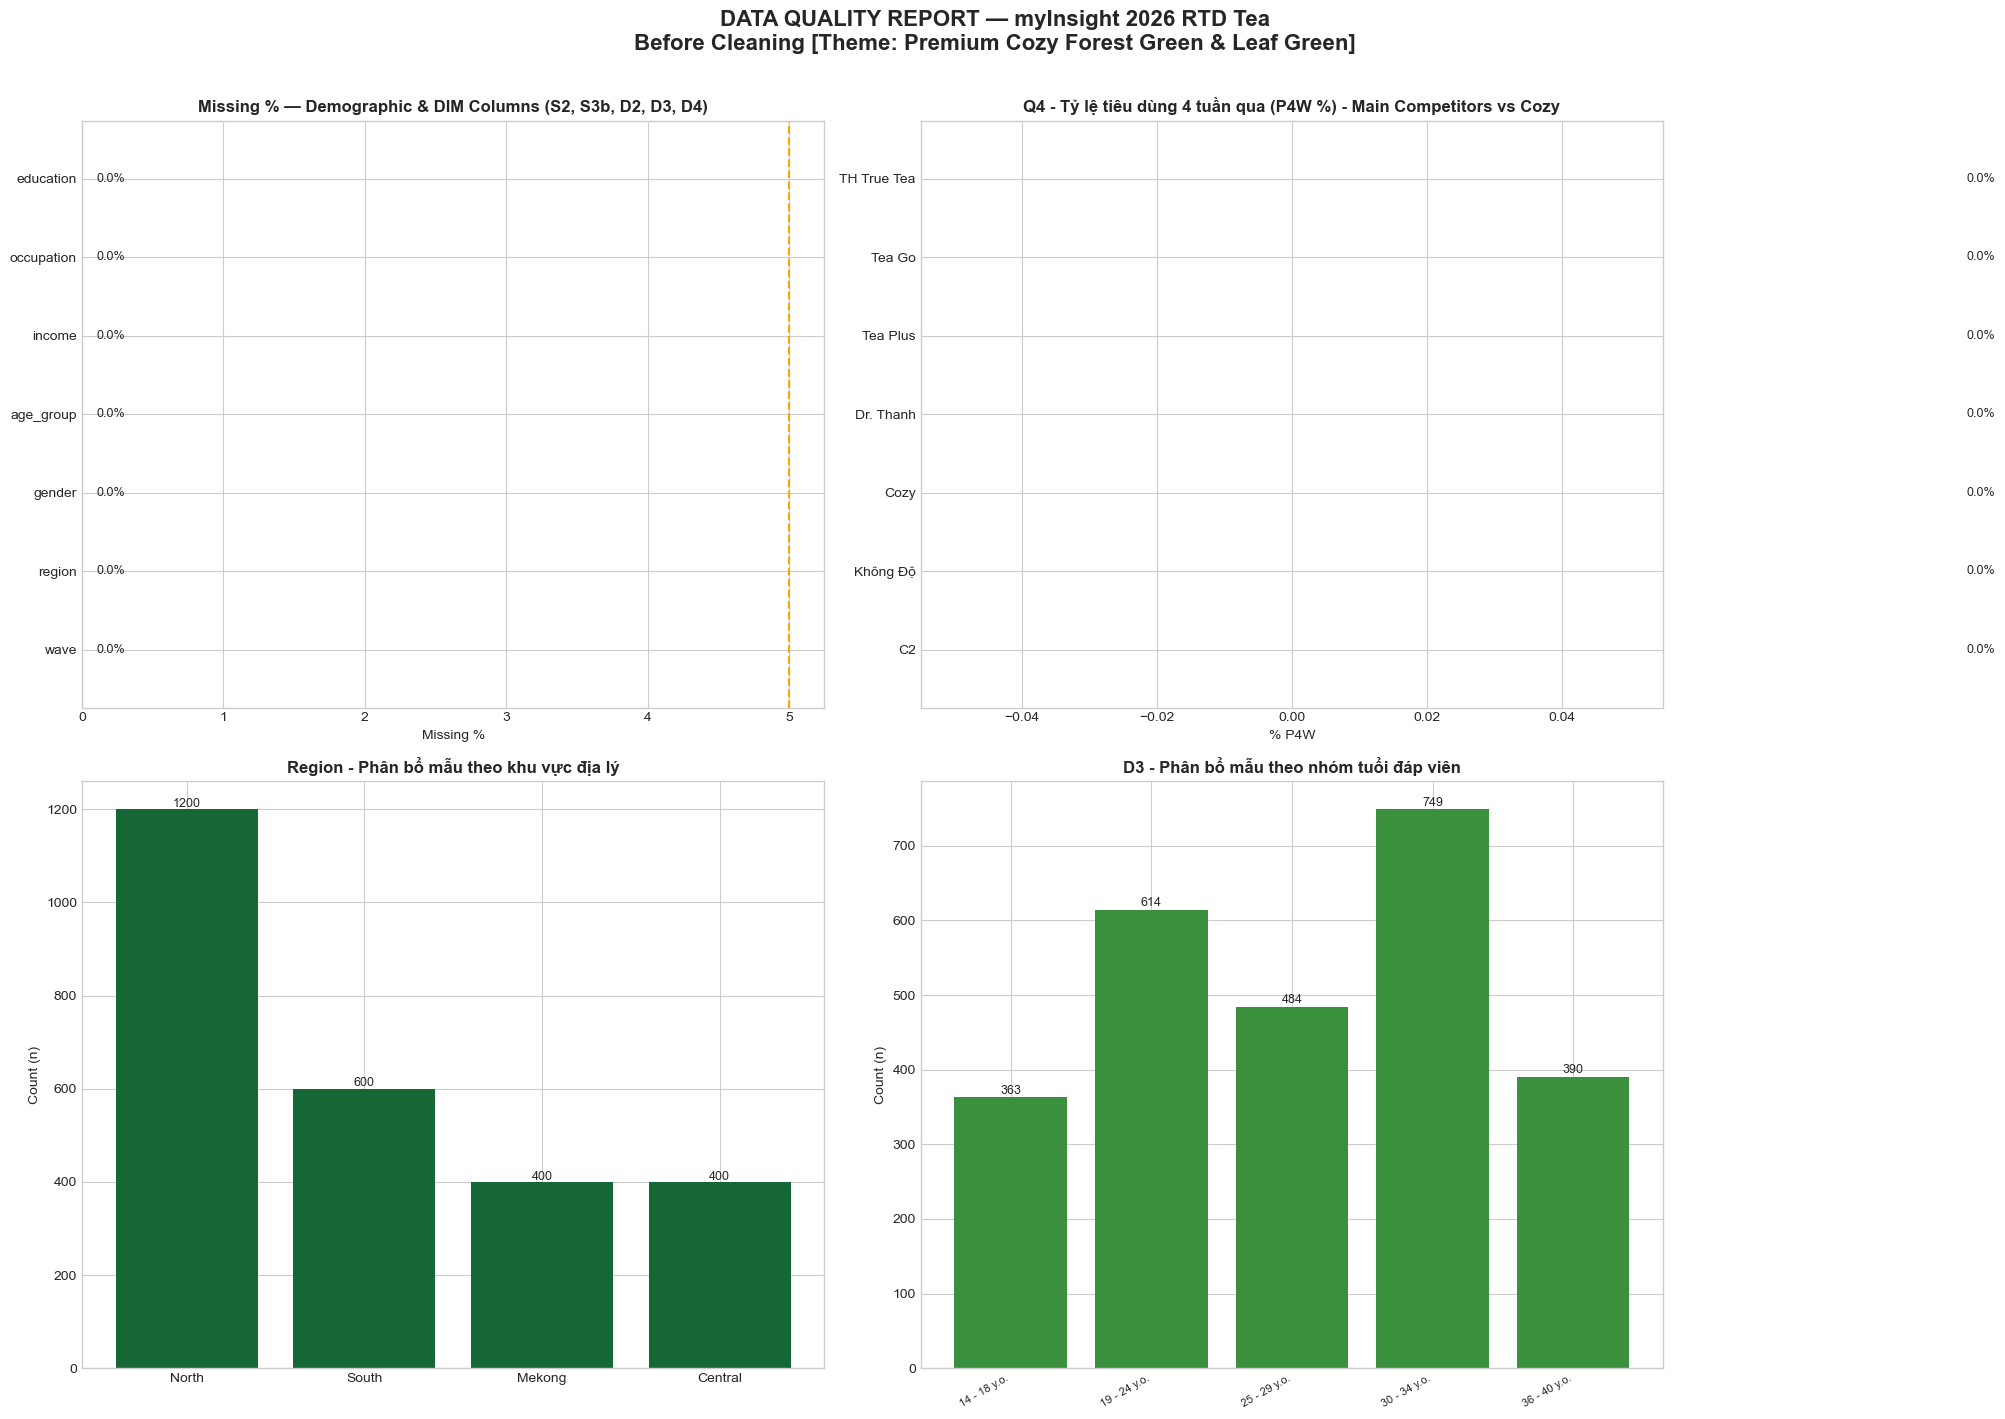

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle('DATA QUALITY REPORT — myInsight 2026 RTD Tea\nBefore Cleaning [Theme: Premium Cozy Forest Green & Leaf Green]',
             fontsize=16, fontweight='bold', y=1.01)

# Chart 1: Tỷ lệ khuyết thiếu các cột DIM
dim_cols = ['wave','region','gender','age_group',
            'income','occupation','education']
missing_dim = df_clean[dim_cols].isnull().mean() * 100

axes[0,0].barh(dim_cols,
               missing_dim,
               color=['#F87171' if v > 5 else '#156835'
                      for v in missing_dim])
axes[0,0].axvline(5, color='orange', linestyle='--',
                  label='5% threshold')
axes[0,0].set_title('Missing % — Demographic & DIM Columns (S2, S3b, D2, D3, D4)',
                    fontweight='bold')
axes[0,0].set_xlabel('Missing %')
for i, v in enumerate(missing_dim):
    axes[0,0].text(v + 0.1, i, f'{v:.1f}%',
                   va='center', fontsize=9)

# Chart 2: Tỷ lệ tiêu dùng 4 tuần qua (P4W)
p4w_cols = {
    'C2': 'Q4. P4W_C2',
    'Không Độ': 'Q4. P4W_Không Độ',
    'Cozy': 'Q4. P4W_Trà Cozy đóng chai',
    'Dr. Thanh': 'Q4. P4W_Dr. Thanh',
    'Tea Plus': 'Q4. P4W_OLong Tea Plus',
    'Tea Go': 'Q4. P4W_Trà Tea Go',
    'TH True Tea': 'Q4. P4W_Trà TH True Tea'
}
p4w_pct = []
p4w_labels = []
for name, col in p4w_cols.items():
    if col in df_clean.columns:
        pct = df_clean[col].mean() * 100
        p4w_pct.append(pct)
        p4w_labels.append(name)

colors = ['#156835' if 'Cozy' in l else '#A7F3D0'
          for l in p4w_labels]
bars = axes[0,1].barh(p4w_labels, p4w_pct, color=colors)
axes[0,1].set_title('Q4 - Tỷ lệ tiêu dùng 4 tuần qua (P4W %) - Main Competitors vs Cozy',
                    fontweight='bold')
axes[0,1].set_xlabel('% P4W')
for bar, val in zip(bars, p4w_pct):
    axes[0,1].text(val + 0.1, bar.get_y() + bar.get_height()/2,
                   f'{val:.1f}%', va='center', fontsize=9)

# Chart 3: Phân phối mẫu theo khu vực
region_counts = df_clean['region'].value_counts()
axes[1,0].bar(region_counts.index,
              region_counts.values,
              color='#156835')
axes[1,0].set_title('Region - Phân bổ mẫu theo khu vực địa lý',
                    fontweight='bold')
axes[1,0].set_ylabel('Count (n)')
for i, val in enumerate(region_counts.values):
    axes[1,0].text(i, val + 5, str(val),
                   ha='center', fontsize=9)

# Chart 4: Phân phối mẫu theo nhóm tuổi
age_counts = df_clean['age_group'].value_counts().sort_index()
axes[1,1].bar(range(len(age_counts)),
              age_counts.values,
              color='#3b903e')
axes[1,1].set_xticks(range(len(age_counts)))
axes[1,1].set_xticklabels(age_counts.index,
                           rotation=30, ha='right',
                           fontsize=8)
axes[1,1].set_title('D3 - Phân bổ mẫu theo nhóm tuổi đáp viên',
                    fontweight='bold')
axes[1,1].set_ylabel('Count (n)')
for i, val in enumerate(age_counts.values):
    axes[1,1].text(i, val + 5, str(val),
                   ha='center', fontsize=9)

plt.tight_layout()
os.makedirs('../charts', exist_ok=True)
plt.savefig('../charts/data_quality_before_clean.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 🔍 CELL 8 — XỬ LÝ DUPLICATE & KIỂM TRA TÍNH TOÀN VẸN (VALIDATION)
Tiến hành loại bỏ bản ghi trùng lặp và xác thực chéo các giá trị đặc biệt giữa các bảng khảo sát và danh mục thương hiệu gốc.


In [10]:
print(f"Shape trước khi xử lý trùng lặp: {df_clean.shape}")

# Bước 1: Kiểm tra trùng lặp theo Serial Number
n_dup_serial = df_clean.duplicated(subset=['serial']).sum()
print(f"⚠️ Số bản ghi trùng lặp theo Serial Number: {n_dup_serial}")
if n_dup_serial > 0:
    df_clean = df_clean.drop_duplicates(
        subset=['serial'], keep='last'
    )

# Bước 2: Kiểm tra trùng lặp giống nhau hoàn toàn toàn bộ dòng
n_dup_full = df_clean.duplicated().sum()
print(f"⚠️ Số dòng trùng lặp hoàn toàn: {n_dup_full}")
if n_dup_full > 0:
    df_clean = df_clean.drop_duplicates(keep='first')

print(f"Shape sau khi xử lý: {df_clean.shape}")

# Bước 3: Validation checks các giá trị cụ thể
print("\n🔍 KẾT QUẢ KIỂM TRA TÍNH TOÀN VẸN DỮ LIỆU:")
print(f"   Wave thực tế: {sorted(df_clean['wave'].dropna().unique())}")
print(f"   Khu vực thực tế: {list(df_clean['region'].unique())}")

# Kiểm tra xem các cột flag có nằm ngoài tập giá trị hợp lệ 0, 1 hay không
sample_flag = col_groups['Q3_P3M'][0]
if sample_flag in df_clean.columns:
    invalid = df_clean[sample_flag][~df_clean[sample_flag].isin([0, 1, np.nan])].unique()
    if len(invalid) > 0:
        print(f"   ⚠️ Lỗi giá trị không hợp lệ trong cột {sample_flag}: {invalid}")
    else:
        print(f"   ✅ Kiểm tra cột Flag: Đạt chuẩn (chỉ chứa 0/1/NaN)")

# Kiểm tra nhãn hiệu xuất hiện trong TOM có tồn tại trong danh sách Brandlist hay không
valid_brands = set(df_brand_clean['brand_name'].str.strip())
tom_vals = set(df_clean['Q1.TOM'].dropna().str.strip().unique())
unknown_brands = tom_vals - valid_brands - {'DK/NA', '98. DK/NA'}
if unknown_brands:
    print(f"   ⚠️ Nhãn hiệu xuất hiện trong TOM nhưng không có trong Brandlist:")
    print(f"      {unknown_brands}")
else:
    print(f"   ✅ Kiểm tra thương hiệu trong TOM: Đạt chuẩn")


Shape trước khi xử lý trùng lặp: (2600, 1068)
⚠️ Số bản ghi trùng lặp theo Serial Number: 0
⚠️ Số dòng trùng lặp hoàn toàn: 0
Shape sau khi xử lý: (2600, 1068)

🔍 KẾT QUẢ KIỂM TRA TÍNH TOÀN VẸN DỮ LIỆU:
   Wave thực tế: [2024, 2025]
   Khu vực thực tế: ['South', 'Mekong', 'North', 'Central']
   ✅ Kiểm tra cột Flag: Đạt chuẩn (chỉ chứa 0/1/NaN)
   ⚠️ Nhãn hiệu xuất hiện trong TOM nhưng không có trong Brandlist:
      {'99. None'}


## 📋 CELL 9 — BẢNG DATA DICTIONARY & CLEANING LOG (STYLIZED & EXPORTED)
Tạo bảng báo cáo tóm tắt chất lượng cho từng nhóm cột, ghi rõ nguồn gốc file của cột, áp dụng màu sắc trực quan bằng Pandas Styler và xuất bản ra Excel.


In [11]:
summary_rows = []

group_meta = {
    'ID':          ('Dataset.csv', 'serial',           'Định danh duy nhất mỗi respondent',  'Định tính', 
                    'Lỗi dấu phẩy thập phân từ Excel gốc (1,00) làm mất dữ liệu', 
                    'Thay thế \',\' thành \'.\' và ép kiểu về Int64'),
    'DIM_Demo':    ('Dataset.csv', 'demo columns',     'Thông tin nhân khẩu học (Khu vực, Giới tính, Tuổi, Thu nhập, Nghề nghiệp, Học vấn)',             
                    'Định tính', 
                    'Dữ liệu chứa khoảng trắng thừa (Whitespace) ở đầu/cuối chuỗi', 
                    'Trim whitespace | Chuẩn hóa chữ cái đầu cho Region'),
    'Q1_TOM':      ('Dataset.csv', 'Q1.TOM',           'Top of Mind — Nhãn hiệu trà uống liền nghĩ đến đầu tiên',    
                    'Định tính', 
                    'Dữ liệu chứa khoảng trắng thừa ở đầu/cuối chuỗi', 
                    'Trim whitespace'),
    'Q1_Spont':    ('Dataset.csv', 'Q1.Spontaneous',   'Nhận biết tự phát các nhãn hiệu tiếp theo (0/1)',    
                    'Định lượng rời rạc', 
                    'Có chứa giá trị rác #NULL! | Yes/No dạng chuỗi chưa tối ưu', 
                    '#NULL! -> NaN | Yes/No -> 1/0'),
    'Q1Q2_Aided':  ('Dataset.csv', 'Q1Q2.Aided',       'Nhận biết có gợi ý của các nhãn hiệu (0/1)',  
                    'Định lượng rời rạc', 
                    'Có chứa giá trị rác #NULL! | Yes/No dạng chuỗi chưa tối ưu', 
                    '#NULL! -> NaN | Yes/No -> 1/0'),
    'Q3_P3M':      ('Dataset.csv', 'Q3.P3M',           'Tiêu dùng trà uống liền trong 3 tháng qua (0/1)',          
                    'Định lượng rời rạc', 
                    'Có chứa giá trị rác #NULL! | Yes/No dạng chuỗi chưa tối ưu', 
                    '#NULL! -> NaN | Yes/No -> 1/0'),
    'Q4_P4W':      ('Dataset.csv', 'Q4.P4W',           'Tiêu dùng trà uống liền trong 4 tuần qua (0/1)',           
                    'Định lượng rời rạc', 
                    'Có chứa giá trị rác #NULL! | Yes/No dạng chuỗi chưa tối ưu', 
                    '#NULL! -> NaN | Yes/No -> 1/0'),
    'Q5_BUMO':     ('Dataset.csv', 'Q5.Bumo',          'Nhãn hiệu trà uống liền dùng thường xuyên nhất trong 4 tuần qua',          
                    'Định tính', 
                    'Dữ liệu chứa khoảng trắng thừa ở đầu/cuối chuỗi', 
                    'Trim whitespace'),
    'Q6_Consid':   ('Dataset.csv', 'Q6.Consideration', 'Tần suất sử dụng cụ thể của từng nhãn hiệu (Chuỗi tần suất)',          
                    'Định tính', 
                    'Có chứa giá trị rác #NULL!', 
                    '#NULL! -> NaN | Trim whitespace'),
    'Q7_PrevBUMO': ('Dataset.csv', 'Q7.PrevBUMO',      'Nhãn hiệu dùng thường xuyên nhất trước khi đổi sang nhãn hiệu hiện tại',                
                    'Định tính', 
                    'Dữ liệu chứa khoảng trắng thừa ở đầu/cuối chuỗi', 
                    'Trim whitespace'),
    'Q4Q8_BCS':    ('Dataset.csv', 'Q4Q8.BCS',         'Tập hợp cân nhắc mua của các nhãn hiệu (0/1)',                
                    'Định lượng rời rạc', 
                    'Có chứa giá trị rác #NULL! | Yes/No dạng chuỗi chưa tối ưu', 
                    '#NULL! -> NaN | Yes/No -> 1/0'),
    'QI_Imagery':  ('Dataset.csv', 'QI.Imagery',       'Đánh giá hình ảnh/thuộc tính thương hiệu (0/1)', 
                    'Định lượng rời rạc', 
                    'Có chứa giá trị rác #NULL! | Yes/No dạng chuỗi chưa tối ưu', 
                    '#NULL! -> NaN | Yes/No -> 1/0'),
    'QME2_Barrier':('Dataset.csv', 'QME2.Barrier',     'Rào cản/Lý do không cân nhắc mua nhãn hiệu (0/1)',          
                    'Định lượng rời rạc', 
                    'Có chứa giá trị rác #NULL! | Yes/No dạng chuỗi chưa tối ưu', 
                    '#NULL! -> NaN | Yes/No -> 1/0'),
    'QTP1_Touch':  ('Dataset.csv', 'Q_TP1.Touchpoint', 'Kênh tiếp xúc truyền thông của nhãn hiệu (0/1)',     
                    'Định lượng rời rạc', 
                    'Có chứa giá trị rác #NULL! | Yes/No dạng chuỗi chưa tối ưu', 
                    '#NULL! -> NaN | Yes/No -> 1/0'),
    'QTP2_PurchCh':('Dataset.csv', 'Q_TP2.PurchCh',    'Kênh mua nhãn hiệu trong lần gần nhất (Chuỗi tên kênh)',                     
                    'Định tính', 
                    'Có chứa giá trị rác #NULL!', 
                    '#NULL! -> NaN | Trim whitespace'),
    'QTP3_Occas':  ('Dataset.csv', 'Q_TP3.Occasion',   'Dịp tiêu dùng nhãn hiệu trong lần gần nhất (Chuỗi dịp)',                
                    'Định tính', 
                    'Có chứa giá trị rác #NULL!', 
                    '#NULL! -> NaN | Trim whitespace'),
}

for grp, cols in col_groups.items():
    if not cols or grp not in group_meta:
        continue
    source_file, repr_col, meaning, classif, error, fix = group_meta[grp]
    
    dtype_orig = df_data[repr_col].dtype if repr_col in df_data.columns else 'object'
    if grp == 'ID':
        dtype_orig = 'object'
        dtype_clean = 'Int64'
    elif grp == 'DIM_Demo':
        dtype_orig = 'object/int64'
        dtype_clean = 'Int64/object'
    elif '0/1' in fix:
        dtype_clean = 'float64'
    else:
        dtype_clean = 'object'
        
    summary_rows.append({
        'Bảng nguồn': source_file,
        'Tên cột': f"{grp} ({len(cols)} cột, VD: {repr_col})",
        'Ý nghĩa': meaning,
        'Kiểu dữ liệu': f"{dtype_orig} ➜ {dtype_clean}",
        'Phân loại(định tính/định lượng)': classif,
        'Lỗi gặp phải': error,
        'Cách clean': fix
    })

# Add Wave
summary_rows.append({
    'Bảng nguồn': 'Dataset.csv',
    'Tên cột': 'Wave',
    'Ý nghĩa': 'Năm thực hiện phỏng vấn (2024/2025)',
    'Kiểu dữ liệu': 'int64 ➜ Int64',
    'Phân loại(định tính/định lượng)': 'Định lượng rời rạc',
    'Lỗi gặp phải': 'Không có lỗi',
    'Cách clean': 'Giữ nguyên'
})

# Add Brandlist meta
summary_rows.append({
    'Bảng nguồn': 'Brandlist_RTDT.csv',
    'Tên cột': 'brand_id, brand_name, is_master_brand, master_brand',
    'Ý nghĩa': 'Danh mục mã số, tên thương hiệu, nhãn hiệu gốc và phân loại SKU cụ thể',
    'Kiểu dữ liệu': 'object/float ➜ Int64/object',
    'Phân loại(định tính/định lượng)': 'Định tính',
    'Lỗi gặp phải': 'Null dòng trống \| Tên chứa khoảng trắng thừa \| Chưa tách SKU',
    'Cách clean': 'Drop null \| Trim whitespace \| Phân loại SKU bằng dấu gạch ngang'
})

# Add QNR Reference meta
summary_rows.append({
    'Bảng nguồn': 'QNR_Reference.csv',
    'Tên cột': 'question_code, question_text, answer_text, answer_code',
    'Ý nghĩa': 'Bảng tra cứu diễn giải chi tiết câu hỏi và bảng mã câu trả lời khảo sát',
    'Kiểu dữ liệu': 'object ➜ object',
    'Phân loại(định tính/định lượng)': 'Định tính',
    'Lỗi gặp phải': 'Merge cell gây Null hàng loạt khi đọc bằng pandas \| Khoảng trắng thừa',
    'Cách clean': 'Forward fill (ffill) mã/nội dung câu hỏi \| Trim whitespace'
})

summary_df = pd.DataFrame(summary_rows)

# Stylers
def style_errors(val):
    if val == 'Không có lỗi':
        return 'background-color: #e0ffe0; color: #006000'
    return 'background-color: #ffe0e0; color: #800000'

def style_classif(val):
    if val == 'Định tính':
        return 'background-color: #fff9e0; color: #604000'
    elif 'Định lượng' in str(val):
        return 'background-color: #e0f0ff; color: #004080'
    return ''

styled_df = (summary_df.style
    .applymap(style_errors, subset=['Lỗi gặp phải'])
    .applymap(style_classif, subset=['Phân loại(định tính/định lượng)'])
    .set_properties(**{
        'text-align': 'left',
        'font-family': 'Arial, sans-serif',
        'font-size': '12px',
        'border': '1px solid #cccccc',
        'padding': '8px'
    })
    .set_table_styles([{
        'selector': 'th',
        'props': [
            ('background-color', '#2c3e50'),
            ('color', 'white'),
            ('font-weight', 'bold'),
            ('text-align', 'center'),
            ('padding', '10px')
        ]
    }])
)

# Export to Excel with openpyxl auto-fit and styling
excel_file = '../../data_dictionary_cleaning_log.xlsx'
with pd.ExcelWriter(excel_file, engine='openpyxl') as writer:
    summary_df.to_excel(writer, sheet_name='Cleaning Log', index=False)
    
    # Auto-fit columns
    sheet = writer.sheets['Cleaning Log']
    for col in sheet.columns:
        max_len = max(len(str(cell.value or '')) for cell in col) + 4
        col_letter = get_column_letter(col[0].column)
        sheet.column_dimensions[col_letter].width = min(max_len, 45)

# Copy to output folder as well
try:
    import shutil
    shutil.copy(excel_file, '../output/data_dictionary_cleaning_log.xlsx')
except:
    pass

print("📋 BẢNG DATA DICTIONARY & CLEANING LOG ĐẦY ĐỦ 7 CỘT (CÓ BẢNG NGUỒN):")
display(styled_df)


📋 BẢNG DATA DICTIONARY & CLEANING LOG ĐẦY ĐỦ 7 CỘT (CÓ BẢNG NGUỒN):


,Bảng nguồn,Tên cột,Ý nghĩa,Kiểu dữ liệu,Phân loại(định tính/định lượng),Lỗi gặp phải,Cách clean
0,Dataset.csv,"ID (1 cột, VD: serial)",Định danh duy nhất mỗi respondent,object ➜ Int64,Định tính,"Lỗi dấu phẩy thập phân từ Excel gốc (1,00) làm mất dữ liệu","Thay thế ',' thành '.' và ép kiểu về Int64"
1,Dataset.csv,"DIM_Demo (7 cột, VD: demo columns)","Thông tin nhân khẩu học (Khu vực, Giới tính, Tuổi, Thu nhập, Nghề nghiệp, Học vấn)",object/int64 ➜ Int64/object,Định tính,Dữ liệu chứa khoảng trắng thừa (Whitespace) ở đầu/cuối chuỗi,Trim whitespace | Chuẩn hóa chữ cái đầu cho Region
2,Dataset.csv,"Q1_TOM (1 cột, VD: Q1.TOM)",Top of Mind — Nhãn hiệu trà uống liền nghĩ đến đầu tiên,object ➜ object,Định tính,Dữ liệu chứa khoảng trắng thừa ở đầu/cuối chuỗi,Trim whitespace
3,Dataset.csv,"Q1_Spont (57 cột, VD: Q1.Spontaneous)",Nhận biết tự phát các nhãn hiệu tiếp theo (0/1),object ➜ object,Định lượng rời rạc,Có chứa giá trị rác #NULL! | Yes/No dạng chuỗi chưa tối ưu,#NULL! -> NaN | Yes/No -> 1/0
4,Dataset.csv,"Q1Q2_Aided (57 cột, VD: Q1Q2.Aided)",Nhận biết có gợi ý của các nhãn hiệu (0/1),object ➜ object,Định lượng rời rạc,Có chứa giá trị rác #NULL! | Yes/No dạng chuỗi chưa tối ưu,#NULL! -> NaN | Yes/No -> 1/0
5,Dataset.csv,"Q3_P3M (16 cột, VD: Q3.P3M)",Tiêu dùng trà uống liền trong 3 tháng qua (0/1),object ➜ object,Định lượng rời rạc,Có chứa giá trị rác #NULL! | Yes/No dạng chuỗi chưa tối ưu,#NULL! -> NaN | Yes/No -> 1/0
6,Dataset.csv,"Q4_P4W (56 cột, VD: Q4.P4W)",Tiêu dùng trà uống liền trong 4 tuần qua (0/1),object ➜ object,Định lượng rời rạc,Có chứa giá trị rác #NULL! | Yes/No dạng chuỗi chưa tối ưu,#NULL! -> NaN | Yes/No -> 1/0
7,Dataset.csv,"Q5_BUMO (1 cột, VD: Q5.Bumo)",Nhãn hiệu trà uống liền dùng thường xuyên nhất trong 4 tuần qua,object ➜ object,Định tính,Dữ liệu chứa khoảng trắng thừa ở đầu/cuối chuỗi,Trim whitespace
8,Dataset.csv,"Q6_Consid (15 cột, VD: Q6.Consideration)",Tần suất sử dụng cụ thể của từng nhãn hiệu (Chuỗi tần suất),object ➜ object,Định tính,Có chứa giá trị rác #NULL!,#NULL! -> NaN | Trim whitespace
9,Dataset.csv,"Q7_PrevBUMO (1 cột, VD: Q7.PrevBUMO)",Nhãn hiệu dùng thường xuyên nhất trước khi đổi sang nhãn hiệu hiện tại,object ➜ object,Định tính,Dữ liệu chứa khoảng trắng thừa ở đầu/cuối chuỗi,Trim whitespace


## 📤 CELL 10 — EXPORT OUTPUT
Xuất bản toàn bộ các bảng dữ liệu sau làm sạch sang định dạng CSV lưu trữ và tệp Excel báo cáo tổng hợp chuyên nghiệp (được tự động hóa kích thước cột).


In [12]:
os.makedirs('../output', exist_ok=True)

# Export 1: Dataset đã clean
df_clean.to_csv('../output/Dataset_cleaned.csv',
                index=False, encoding='utf-8-sig')
print("✅ Exported: output/Dataset_cleaned.csv")

# Export 2: Brandlist đã clean
df_brand_clean.to_csv('../output/Brandlist_cleaned.csv',
                       index=False, encoding='utf-8-sig')
print("✅ Exported: output/Brandlist_cleaned.csv")

# Export 3: QNR Reference đã clean
df_qnr_clean.to_csv('../output/QNR_Reference_cleaned.csv',
                     index=False, encoding='utf-8-sig')
print("✅ Exported: output/QNR_Reference_cleaned.csv")

# Export 4: Cleaning report Excel
with pd.ExcelWriter('../output/cleaning_report_myInsight2026.xlsx',
                    engine='openpyxl') as writer:

    summary_df.to_excel(
        writer, 
        sheet_name='Cleaning Summary',
        index=False
    )
    df_clean[['serial','wave','region','gender',
              'age_group','income']].head(500).to_excel(
        writer,
        sheet_name='Dataset Preview',
        index=False
    )
    df_brand_clean.to_excel(
        writer,
        sheet_name='Brandlist',
        index=False
    )
    df_qnr_clean.to_excel(
        writer,
        sheet_name='QNR Reference',
        index=False
    )

    # Tự động hóa độ rộng cột trong các sheet Excel
    for sheet in writer.sheets.values():
        for col in sheet.columns:
            max_len = max(
                len(str(cell.value or ''))
                for cell in col
            ) + 4
            sheet.column_dimensions[
                get_column_letter(col[0].column)
            ].width = min(max_len, 45)

print("✅ Exported: output/cleaning_report_myInsight2026.xlsx")


✅ Exported: output/Dataset_cleaned.csv
✅ Exported: output/Brandlist_cleaned.csv
✅ Exported: output/QNR_Reference_cleaned.csv
✅ Exported: output/cleaning_report_myInsight2026.xlsx


## 🏁 CELL 11 — FINAL SUMMARY & RE-CHECK
Báo cáo tóm tắt tổng quan dữ liệu thu được sau toàn bộ tiến trình làm sạch và định hướng phân tích chuyên sâu cho các giai đoạn tiếp theo.


In [13]:
print("="*55)
print("     CLEANING FINAL REPORT — myInsight 2026")
print("="*55)
print(f"  Dataset gốc  : {df_data.shape[0]:,} dòng × {df_data.shape[1]:,} cột")
print(f"  Dataset clean: {df_clean.shape[0]:,} dòng × {df_clean.shape[1]:,} cột")
print(f"  Dòng bị xóa  : {df_data.shape[0] - df_clean.shape[0]:,}")
print()
print(f"  #NULL! xử lý : {null_str_count:,} ô → NaN")
print(f"  Yes/No → 0/1 : {converted} cột")
print(f"  Brands trong Brandlist: {len(df_brand_clean)}")
print(f"  Questions trong QNR   : {len(df_qnr_clean)}")
print("="*55)

     CLEANING FINAL REPORT — myInsight 2026
  Dataset gốc  : 2,600 dòng × 1,068 cột
  Dataset clean: 2,600 dòng × 1,068 cột
  Dòng bị xóa  : 0

  #NULL! xử lý : 1,346,028 ô → NaN
  Yes/No → 0/1 : 1011 cột
  Brands trong Brandlist: 55
  Questions trong QNR   : 206
